# Tabular Kaggle Project

## Define Project

**Project link:** Santander Customer Satisfaction Dataset (Kaggle)

This project uses the Santander Customer Satisfaction dataset to predict whether a bank customer is dissatisfied. The challenge is a binary classification problem. The model uses anonymized numerical customer features to predict the target variable `TARGET`.

`TARGET = 0` means the customer is satisfied. `TARGET = 1` means the customer is dissatisfied.

The data is tabular because each customer is represented by one row and each feature is represented by one column. The dataset contains 76,020 customers, 369 anonymized numerical features, one ID column, and one target column. The main challenge is class imbalance because only about 4% of customers are dissatisfied.


## Data Loading and Initial Look

In this section, I load the dataset, count the rows and features, check missing values, inspect feature types, define outliers, examine class imbalance, and describe the target encoding.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

train = pd.read_csv("train.csv")
print("Data loaded successfully.")


Data loaded successfully.


In [22]:
train.head()


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,imp_op_var39_efect_ult1,imp_op_var39_efect_ult3,imp_op_var39_ult1,imp_sal_var16_ult1,ind_var1_0,ind_var1,ind_var2_0,ind_var2,ind_var5_0,ind_var5,ind_var6_0,ind_var6,ind_var8_0,ind_var8,ind_var12_0,ind_var12,ind_var13_0,ind_var13_corto_0,ind_var13_corto,ind_var13_largo_0,ind_var13_largo,ind_var13_medio_0,ind_var13_medio,ind_var13,ind_var14_0,ind_var14,ind_var17_0,ind_var17,ind_var18_0,ind_var18,ind_var19,ind_var20_0,ind_var20,ind_var24_0,ind_var24,ind_var25_cte,ind_var26_0,ind_var26_cte,ind_var26,ind_var25_0,ind_var25,ind_var27_0,ind_var28_0,ind_var28,ind_var27,ind_var29_0,ind_var29,ind_var30_0,ind_var30,ind_var31_0,ind_var31,ind_var32_cte,ind_var32_0,ind_var32,ind_var33_0,ind_var33,ind_var34_0,ind_var34,ind_var37_cte,ind_var37_0,ind_var37,ind_var39_0,ind_var40_0,ind_var40,ind_var41_0,ind_var41,ind_var39,ind_var44_0,ind_var44,ind_var46_0,ind_var46,num_var1_0,num_var1,num_var4,num_var5_0,num_var5,num_var6_0,num_var6,num_var8_0,num_var8,num_var12_0,num_var12,num_var13_0,num_var13_corto_0,num_var13_corto,num_var13_largo_0,num_var13_largo,num_var13_medio_0,num_var13_medio,num_var13,num_var14_0,num_var14,num_var17_0,num_var17,num_var18_0,num_var18,num_var20_0,num_var20,num_var24_0,num_var24,num_var26_0,num_var26,num_var25_0,num_var25,num_op_var40_hace2,num_op_var40_hace3,num_op_var40_ult1,num_op_var40_ult3,num_op_var41_hace2,num_op_var41_hace3,num_op_var41_ult1,num_op_var41_ult3,num_op_var39_hace2,num_op_var39_hace3,num_op_var39_ult1,num_op_var39_ult3,num_var27_0,num_var28_0,num_var28,num_var27,num_var29_0,num_var29,num_var30_0,num_var30,num_var31_0,num_var31,num_var32_0,num_var32,num_var33_0,num_var33,num_var34_0,num_var34,num_var35,num_var37_med_ult2,num_var37_0,num_var37,num_var39_0,num_var40_0,num_var40,num_var41_0,num_var41,num_var39,num_var42_0,num_var42,num_var44_0,num_var44,num_var46_0,num_var46,saldo_var1,saldo_var5,saldo_var6,saldo_var8,saldo_var12,saldo_var13_corto,saldo_var13_largo,saldo_var13_medio,saldo_var13,saldo_var14,saldo_var17,saldo_var18,saldo_var20,saldo_var24,saldo_var26,saldo_var25,saldo_var28,saldo_var27,saldo_var29,saldo_var30,saldo_var31,saldo_var32,saldo_var33,saldo_var34,saldo_var37,saldo_var40,saldo_var41,saldo_var42,saldo_var44,saldo_var46,var36,delta_imp_amort_var18_1y3,delta_imp_amort_var34_1y3,delta_imp_aport_var13_1y3,delta_imp_aport_var17_1y3,delta_imp_aport_var33_1y3,delta_imp_compra_var44_1y3,delta_imp_reemb_var13_1y3,delta_imp_reemb_var17_1y3,delta_imp_reemb_var33_1y3,delta_imp_trasp_var17_in_1y3,delta_imp_trasp_var17_out_1y3,delta_imp_trasp_var33_in_1y3,delta_imp_trasp_var33_out_1y3,delta_imp_venta_var44_1y3,delta_num_aport_var13_1y3,delta_num_aport_var17_1y3,delta_num_aport_var33_1y3,delta_num_compra_var44_1y3,delta_num_reemb_var13_1y3,delta_num_reemb_var17_1y3,delta_num_reemb_var33_1y3,delta_num_trasp_var17_in_1y3,delta_num_trasp_var17_out_1y3,delta_num_trasp_var33_in_1y3,delta_num_trasp_var33_out_1y3,delta_num_venta_var44_1y3,imp_amort_var18_hace3,imp_amort_var18_ult1,imp_amort_var34_hace3,imp_amort_var34_ult1,imp_aport_var13_hace3,imp_aport_var13_ult1,imp_aport_var17_hace3,imp_aport_var17_ult1,imp_aport_var33_hace3,imp_aport_var33_ult1,imp_var7_emit_ult1,imp_var7_recib_ult1,imp_compra_var44_hace3,imp_compra_var44_ult1,imp_reemb_var13_hace3,imp_reemb_var13_ult1,imp_reemb_var17_hace3,imp_reemb_var17_ult1,imp_reemb_var33_hace3,imp_reemb_var33_ult1,imp_var43_emit_ult1,imp_trans_var37_ult1,imp_trasp_var17_in_hace3,imp_trasp_var17_in_ult1,imp_trasp_var17_out_hace3,imp_trasp_var17_out_ult1,imp_trasp_var33_in_hace3,imp_trasp_var33_in_ult1,imp_trasp_var33_out_hace3,imp_trasp_var33_out_ult1,imp_venta_var44_hace3,imp_venta_var44_ult1,ind_var7_emit_ult1,ind_var7_recib_ult1,ind_var10_ult1,ind_var10

In [3]:
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])
print("Predictor features:", train.shape[1] - 2)


Rows: 76020
Columns: 371
Predictor features: 369


In [4]:
print("Total missing values:", train.isnull().sum().sum())


Total missing values: 0


In [23]:
feature_summary = pd.DataFrame({
    "Feature / collection": ["ID", "TARGET", "var* features", "imp_* features", "ind_* features", "num_* features", "saldo_* features", "delta_* features"],
    "Type": ["Numerical identifier", "Binary classification target", "Numerical", "Numerical", "Numerical / indicator", "Numerical count", "Numerical balance", "Numerical change ratio"],
    "Values / range": ["1 to 151838", "0 = satisfied, 1 = dissatisfied", "var3, var15, var21, var36, var38", "transaction amounts", "mostly 0/1 indicators", "counts of operations/products", "account balance values", "change ratios, often -1/0/1"],
    "Missing values": [0, 0, 0, 0, 0, 0, 0, 0],
    "Outliers?": ["No", "No", "Yes", "Yes", "Limited", "Yes", "Yes", "Yes"]
})
feature_summary


,Feature / collection,Type,Values / range,Missing values,Outliers?
0,ID,Numerical identifier,1 to 151838,0,No
1,TARGET,Binary classification target,"0 = satisfied, 1 = dissatisfied",0,No
2,var* features,Numerical,"var3, var15, var21, var36, var38",0,Yes
3,imp_* features,Numerical,transaction amounts,0,Yes
4,ind_* features,Numerical / indicator,mostly 0/1 indicators,0,Limited
5,num_* features,Numerical count,counts of operations/products,0,Yes
6,saldo_* features,Numerical balance,account balance values,0,Yes
7,delta_* features,Numerical change ratio,"change ratios, often -1/0/1",0,Yes


In [24]:
print(train["TARGET"].value_counts())
print()
print(train["TARGET"].value_counts(normalize=True) * 100)


TARGET
0    73012
1     3008
Name: count, dtype: int64

TARGET
0    96.043147
1     3.956853
Name: proportion, dtype: float64


### Initial Data Notes

The dataset has 76,020 rows and 371 columns. The `ID` column identifies rows, not customer behavior, so it should not be used as a machine learning feature. The target column is `TARGET`, with `0` representing satisfied customers and `1` representing dissatisfied customers.

There are no missing values in the dataset. All predictor columns are numerical, so one-hot encoding is not needed. Some financial and balance features contain large extreme values. I define an outlier as a value that is unusually far from the main distribution of a feature, especially values that would fall beyond normal interquartile range behavior.

There is strong class imbalance. About 96% of customers are satisfied, while only about 4% are dissatisfied. Because of this, accuracy alone is not enough to judge model performance.


## Data Visualization

For classification, the instructions ask to compare features between classes. Since this dataset has hundreds of features, plotting every feature would make the notebook unreadable. I used the target distribution and a few representative numerical features to show the class imbalance and compare feature behavior between satisfied and dissatisfied customers.


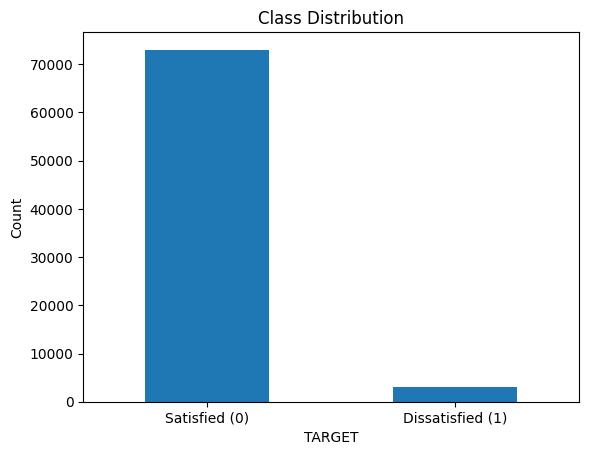

In [25]:
train["TARGET"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.xticks([0, 1], ["Satisfied (0)", "Dissatisfied (1)"], rotation=0)
plt.show()


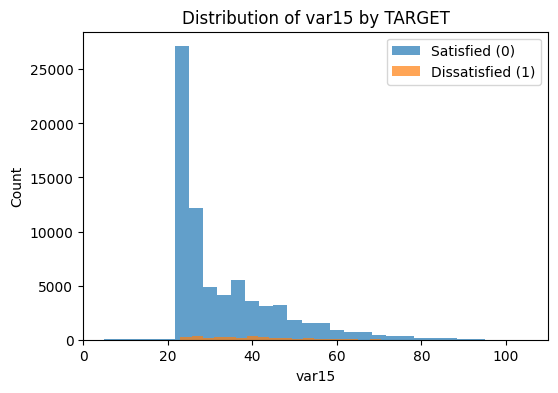

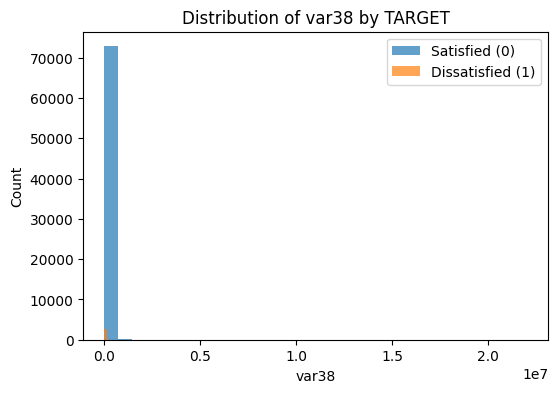

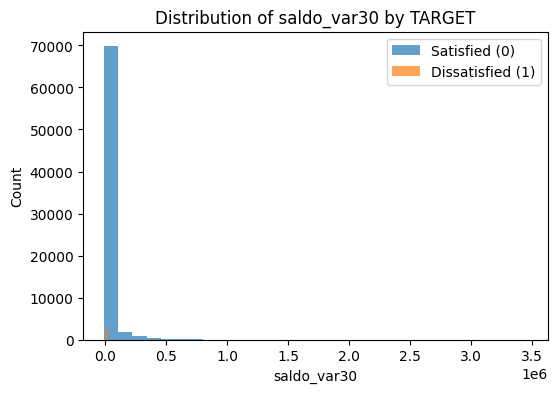

In [26]:
features_to_plot = ["var15", "var38", "saldo_var30"]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(train.loc[train["TARGET"] == 0, feature], bins=30, alpha=0.7, label="Satisfied (0)")
    plt.hist(train.loc[train["TARGET"] == 1, feature], bins=30, alpha=0.7, label="Dissatisfied (1)")
    plt.title(f"Distribution of {feature} by TARGET")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.show()


### Data Visualization Notes

The class distribution plot confirms that the dataset is heavily imbalanced. The dissatisfied class is much smaller than the satisfied class.

The feature histograms show that single features do not perfectly separate the two classes. This suggests that the model must combine many numerical features together to find useful patterns. Features related to age-like behavior (`var15`) and account balance-like behavior (`var38`, `saldo_var30`) appear more promising than many near-constant indicator features.


## Data Cleaning and Preperation for Machine Learning

In this section, I remove features that do not help prediction, check duplicates, determine whether rescaling is important, and prepare the data for machine learning.


In [9]:
constant_cols = [col for col in train.columns if train[col].nunique(dropna=False) <= 1]
print("Number of constant columns:", len(constant_cols))
print(constant_cols[:10])


Number of constant columns: 34
['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0']


In [10]:
train_clean = train.drop(columns=constant_cols)
print("Original shape:", train.shape)
print("Shape after removing constant columns:", train_clean.shape)


Original shape: (76020, 371)
Shape after removing constant columns: (76020, 337)


In [11]:
print("Duplicate rows:", train_clean.duplicated().sum())
train_clean = train_clean.drop_duplicates()
print("Shape after duplicate removal:", train_clean.shape)


Duplicate rows: 0
Shape after duplicate removal: (76020, 337)


### Cleaning Notes

The `ID` column is not used for prediction because it identifies specific rows. Constant columns are removed because they contain the same value for every customer and cannot help separate satisfied from dissatisfied customers.

Rescaling is important for Logistic Regression because that algorithm is sensitive to feature magnitude. I use `StandardScaler` to standardize the features. No categorical features are present, so one-hot encoding is not required.


## Machine Learning

### Problem Formulation

This is a binary classification task. The predictors are the anonymized numerical customer features, and the target is `TARGET`.

Before training, I remove unnecessary columns such as `ID`, keep the target properly encoded as 0 and 1, scale the predictors, and split the data into training and test samples.


In [12]:
X = train_clean.drop(["ID", "TARGET"], axis=1)
y = train_clean["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (76020, 335)
Target shape: (76020,)


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (60816, 335)
Test shape: (15204, 335)


### Train ML Algorithm

I trained three models using the same overall method from my original notebook:

1. Logistic Regression with class balancing
2. Random Forest with class balancing
3. Gradient Boosting

Class balancing is used for Logistic Regression and Random Forest because the dissatisfied class is much smaller than the satisfied class.


In [14]:
log_reg = LogisticRegression(max_iter=500, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
gb = GradientBoostingClassifier(random_state=42)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("Models trained successfully.")


Models trained successfully.


### Evaluate Performance on Validation Sample

I evaluate each model using accuracy, precision, recall, F1 score, and ROC AUC. Since the data is imbalanced, recall, F1 score, and AUC are more meaningful than accuracy alone.


In [27]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

results = [
    evaluate_model("Logistic Regression", log_reg, X_test, y_test),
    evaluate_model("Random Forest", rf, X_test, y_test),
    evaluate_model("Gradient Boosting", gb, X_test, y_test)
]

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.684228,0.090021,0.765781,0.161104,0.803532
1,Random Forest,0.942712,0.166253,0.111296,0.133333,0.757946
2,Gradient Boosting,0.959879,0.166667,0.003322,0.006515,0.842899


In [29]:
print("Logistic Regression")
print(classification_report(y_test, log_reg.predict(X_test), zero_division=0))

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test), zero_division=0))

print("Gradient Boosting")
print(classification_report(y_test, gb.predict(X_test), zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.68      0.81     14602
           1       0.09      0.77      0.16       602

    accuracy                           0.68     15204
   macro avg       0.54      0.72      0.48     15204
weighted avg       0.95      0.68      0.78     15204

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14602
           1       0.17      0.11      0.13       602

    accuracy                           0.94     15204
   macro avg       0.57      0.54      0.55     15204
weighted avg       0.93      0.94      0.94     15204

Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14602
           1       0.17      0.00      0.01       602

    accuracy                           0.96     15204
   macro avg       0.56      0.50      0.49     15204
weighted avg       0.9

In [30]:
cm = confusion_matrix(y_test, log_reg.predict(X_test))
print("Confusion Matrix for Logistic Regression")
print(cm)


Confusion Matrix for Logistic Regression
[[9942 4660]
 [ 141  461]]


### Performance Notes

Logistic Regression is the best model for detecting dissatisfied customers because it has the highest recall for the minority class. It catches many dissatisfied customers, but it also creates many false positives.

Random Forest has high accuracy, but it misses many dissatisfied customers. Gradient Boosting has a strong AUC, but its recall for the dissatisfied class is extremely low.

This shows why accuracy alone is misleading for imbalanced classification. A model can look accurate while failing to detect the minority class.


## Conclusion

This project follows the tabular Kaggle classification workflow using the Santander Customer Satisfaction dataset. The main challenge is class imbalance because only about 4% of customers are dissatisfied.

Logistic Regression with class balancing produced the best recall for the dissatisfied class. Random Forest and Gradient Boosting had higher accuracy, but they were less effective at identifying dissatisfied customers.

The most important lesson from this project is that accuracy is not enough for imbalanced classification. Precision, recall, F1 score, and ROC AUC are needed to understand whether the model is actually finding the minority class.
